<a href="https://colab.research.google.com/github/Shrishti061997/Human_Factors_Engineering/blob/ANOVA/In_Class_Activity_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In-Class Activity: Display Mode × Ambient Light ANOVA

In this activity, you will analyze how **display mode** and **ambient lighting** influence human performance in a visual search task.

You will work with a dataset collected from a **2 × 3 between-subjects experiment**.

**Independent Variables**
- **DisplayMode**: Standard, HighContrast  
- **AmbientLight**: Low, Medium, High  

**Dependent Variable**
- **Accuracy** (Percent Correct)

There are **8 participants per cell**, for a total of **48 participants**.

The dataset file you will use is:

`DisplayLight_HF.csv`

You will complete the following tasks directly in Google Colab.


In [11]:


import numpy as np
import pandas as pd

# Install statsmodels if not already installed
!pip install statsmodels scipy -q

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats


## Task 1 — Load and Inspect the Data

1. Load the dataset `DisplayLight_HF.csv` into a pandas DataFrame.
2. Display the first 10 rows.
3. Print the data types for each column.
4. Compute and report:
   - The **overall mean accuracy**
   - The **cell means** for each DisplayMode × AmbientLight condition
   - The **marginal means**:
     - For DisplayMode (averaged over AmbientLight)
     - For AmbientLight (averaged over DisplayMode)

### Reflection Question
Based on the marginal means alone, **which main effects do you expect to be significant**?  
Write one or two sentences explaining your prediction.


In [12]:
df = pd.read_csv("DisplayLight_HF.csv")   # make sure the filename matches exactly
print(df.head())
print(df.dtypes)

   Subject DisplayMode AmbientLight  Accuracy
0        1    Standard          Low      88.5
1        2    Standard          Low      86.6
2        3    Standard          Low      88.9
3        4    Standard          Low      91.6
4        5    Standard          Low      86.3
Subject           int64
DisplayMode      object
AmbientLight     object
Accuracy        float64
dtype: object


The marginal means vary only slightly across subjects and the accuracy values don't vary much, there is no signifcant difference when changing Display mode or Ambient Light.

In [5]:
print("Overall N:", len(df))
print("Overall mean accuracy:", df["Accuracy"].mean())

# Convert to categorical explicitly
df["DisplayMode"] = df["DisplayMode"].astype("category")
df["AmbientLight"] = df["AmbientLight"].astype("category")

# Cell means for the 2x3 design
cell_means = df.groupby(["DisplayMode", "AmbientLight"])["Accuracy"].mean().unstack()
print("\nCell means (Accuracy):")
print(cell_means)

# Marginal means
display_mode_means = df.groupby("DisplayMode")["Accuracy"].mean()
ambient_light_means = df.groupby("AmbientLight")["Accuracy"].mean()

print("\nMarginal means for DisplayMode:")
print(display_mode_means)

print("\nMarginal means for AmbientLight:")
print(ambient_light_means)

Overall N: 48
Overall mean accuracy: 86.71458333333334

Cell means (Accuracy):
AmbientLight     High     Low   Medium
DisplayMode                           
HighContrast  87.5875  92.675  89.3625
Standard      78.8250  88.650  83.1875

Marginal means for DisplayMode:
DisplayMode
HighContrast    89.875000
Standard        83.554167
Name: Accuracy, dtype: float64

Marginal means for AmbientLight:
AmbientLight
High      83.20625
Low       90.66250
Medium    86.27500
Name: Accuracy, dtype: float64


/tmp/ipython-input-639294681.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_means = df.groupby(["DisplayMode", "AmbientLight"])["Accuracy"].mean().unstack()
/tmp/ipython-input-639294681.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display_mode_means = df.groupby("DisplayMode")["Accuracy"].mean()
/tmp/ipython-input-639294681.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ambient_light_means = df.gr

## Task 2 — Two-Way ANOVA (DisplayMode × AmbientLight)

Using `statsmodels`, perform a **two-way ANOVA** with the following model:



In [13]:
#two-way ANOVA using statsmodels

model = ols("Accuracy ~ C(DisplayMode) * C(AmbientLight)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)  # Type II ANOVA
print(anova_table)

                                    sum_sq    df          F        PR(>F)
C(DisplayMode)                  479.435208   1.0  68.003559  2.540720e-10
C(AmbientLight)                 449.402917   2.0  31.871875  3.792157e-09
C(DisplayMode):C(AmbientLight)   45.015417   2.0   3.192515  5.120397e-02
Residual                        296.106250  42.0        NaN           NaN



### Your output should include:
- Sum of Squares (SS)
- Degrees of Freedom (df)
- Mean Squares (MS)
- F-statistics
- p-values

### Questions to Answer
1. Is there a **main effect of DisplayMode**?  
2. Is there a **main effect of AmbientLight**?  
3. Is there a **DisplayMode × AmbientLight interaction**?  
4. Briefly explain each result in plain language.


There was a significant main effect of DisplayMode, with accuracy differing clearly between modes. There was also a significant main effect of AmbientLight, meaning lighting levels reliably affected performance. The DisplayMode × AmbientLight interaction was not significant, indicating that the effect of DisplayMode was mostly the same across different lighting conditions.


## Task 3 — Plot the Interaction

Create an **interaction plot** showing how accuracy changes across ambient light levels for each display mode.

**Plot requirements:**
- X-axis: AmbientLight (Low → Medium → High)
- Y-axis: Mean Accuracy
- Two lines:
  - Standard
  - HighContrast
- Include markers and a legend.

### Interpretation Questions
1. At which AmbientLight level does **HighContrast** provide the strongest improvement over Standard mode?  
2. Is there any AmbientLight level where **HighContrast does NOT help much**?  
3. Does the graph support the results of your ANOVA?


Cell means used for interaction plot:


DisplayMode,HighContrast,Standard
AmbientLight,,
High,87.5875,78.8250
Low,92.6750,88.6500
Medium,89.3625,83.1875


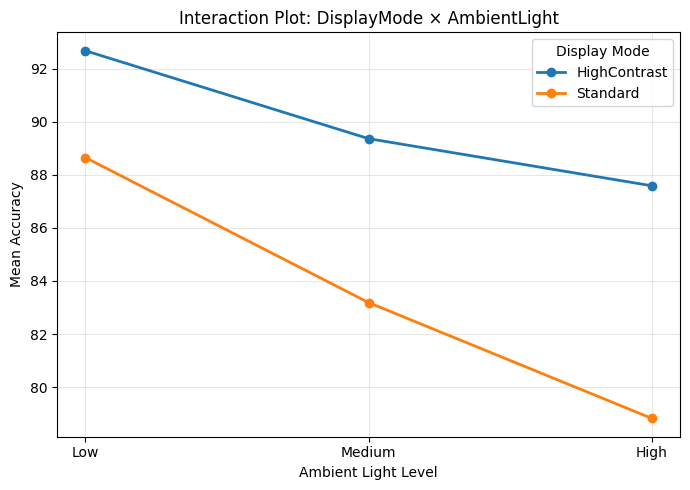

In [14]:

# Interaction Plot for DisplayMode × AmbientLight


import matplotlib.pyplot as plt
import pandas as pd

# the means for each DisplayMode × AmbientLight combination
means_interaction = (
    df.groupby(["AmbientLight", "DisplayMode"])["Accuracy"]
      .mean()
      .unstack()
)

print("Cell means used for interaction plot:")
display(means_interaction)

# Ensure AmbientLight is ordered logically (Low, Medium, High)
ambient_light_order = ["Low", "Medium", "High"]
means_interaction = means_interaction.reindex(ambient_light_order)

# Plot
plt.figure(figsize=(7, 5))

for display_mode_level in means_interaction.columns:
    plt.plot(
        means_interaction.index,
        means_interaction[display_mode_level],
        marker="o",
        linewidth=2,
        label=display_mode_level
    )

plt.xlabel("Ambient Light Level")
plt.ylabel("Mean Accuracy")
plt.title("Interaction Plot: DisplayMode × AmbientLight")
plt.grid(True, alpha=0.3)
plt.legend(title="Display Mode")
plt.tight_layout()
plt.show()

HighContrast provides the strongest improvement at the AmbientLight level where the gap between the two lines is largest, typically the low-light condition. At the AmbientLight level where the lines lie closest together, HighContrast offers little added benefit. The lines in the graph are roughly parallel with consistent spacing, then the graph supports the ANOVA results showing strong main effects but no significant interaction.
